# CSE2530 Computational Intelligence
## Assignment 1: Artificial Neural Networks

|    Group   |           61          |
|------------|----------------------|
| Student A  |        Eva Miesen (5705304) |
| Student B  |        Iasonas Chronis (6167608) |
| Student C  |        Guy Barel (6124607) |
| Student D  |        Miłosz Dudała (6212743) |

### 1.1 Set-up

#### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import copy

#### Seed

In [2]:
# Fixed seed ensures reproducibility across notebook reruns
np.random.seed(13)

#### Loading the data

In [3]:
features = np.genfromtxt("../data/features.txt", delimiter=",")
targets = np.genfromtxt("../data/targets.txt", delimiter=",")
unknown = np.genfromtxt("../data/unknown.txt", delimiter=",")

#### Data Split

In [4]:
# 80-20 train test split
split = int(0.8 * len(features))
indices = np.arange(len(features))
np.random.shuffle(indices)

features_train, features_test = features[indices[:split]], features[indices[split:]]
targets_train, targets_test = targets[indices[:split]], targets[indices[split:]]

# Z-score normalisation
mean = features_train.mean(axis=0)
std = features_train.std(axis=0)
std[std == 0] = 1  # prevent division by zero

features_train = (features_train - mean) / std
features_test = (features_test - mean) / std
unknown = (unknown - mean) / std

### 1.2 Architecture

#### Question 1: Train a Perceptron on AND, OR, and XOR. Show that the perceptron can learn AND and OR but not XOR.

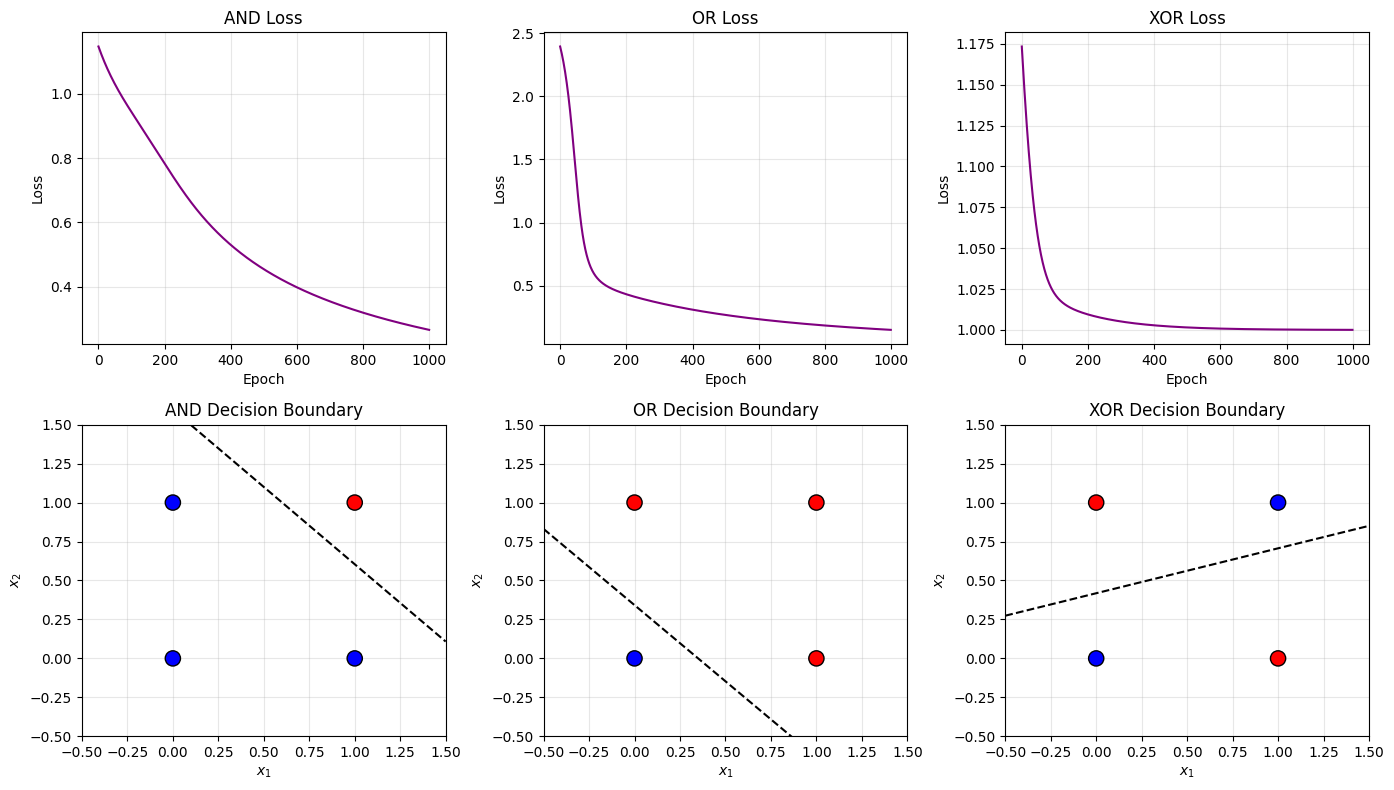

In [5]:
# Functions
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def train_perceptron(X, y, epochs=1000, lr=0.1):
    """Train a single perceptron with sigmoid activation."""
    X, y = np.array(X, dtype=float), np.array(y, dtype=float).reshape(-1, 1)
    w, b = np.random.randn(X.shape[1], 1), np.random.randn()
    losses = []

    # Train the perceptron
    for _ in range(epochs):
        z = X @ w + b
        h = sigmoid(z)
        losses.append(np.sum((y - h) ** 2))
        dz = -2 * (y - h) * h * (1 - h)
        w -= lr * (X.T @ dz) / len(X)
        b -= lr * np.sum(dz) / len(X)

    return w, b, losses

# Train and plot all three gates
gates = {"AND": [0,0,0,1], "OR": [0,1,1,1], "XOR": [0,1,1,0]}
X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for col, (name, y_vals) in enumerate(gates.items()):
    y = np.array(y_vals, dtype=float)
    w, b, losses = train_perceptron(X, y)

    # Loss curve
    axes[0, col].plot(losses, color='purple')
    axes[0, col].set_title(f'{name} Loss')
    axes[0, col].set_xlabel('Epoch')
    axes[0, col].set_ylabel('Loss')
    axes[0, col].grid(True, alpha=0.3)

    # Decision boundary
    ax = axes[1, col]
    colors = ['red' if yi == 1 else 'blue' for yi in y]
    ax.scatter(X[:, 0], X[:, 1], c=colors, s=120, edgecolors='k', zorder=3)

    w0, w1 = w.flatten()
    x_line = np.linspace(-0.5, 1.5, 200)
    if abs(w1) > 1e-10:
        ax.plot(x_line, -(w0 * x_line + b) / w1, 'k--')
    else:
        ax.axvline(x=-b / w0, color='k', linestyle='--')

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_title(f'{name} Decision Boundary')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

For `OR` and `AND` gates the loss curve approaches zero and the final decision boundary cleanly separates the two classes. This shows that the perceptron successfully learned a linear separator that matches the corresponding truth table.

On the other hand, for the `XOR` gate, the loss decreases monotonically but plateaus at 1. The final decision boundary fails to separate the opposing classes, showing the `XOR` is not linearly separable. Thus a single perceptron cannot represent an `XOR` gate.

#### Question 2: How many input neurons are needed in our classification task as described above?

The number of input neurons is fixed by the number of features in the input data. Since we have 10 features, we need 10 input neurons.

#### Question 3: How many output neurons do you require?

The number of output neurons is fixed by the task type. Since the task is to classify objects into multiple separate classes, one ouput neuron per class is required. Since there are 7 classes, the network will have 7 output neurons.

#### Question 4: How many hidden neurons and layers will your network have?

We use **1 hidden layer with 16 neurons**. A single hidden layer is sufficient for our dataset of 10 features and 7 classes. Common heuristics suggest 8–14 neurons (mean of input/output sizes, or the 2/3 rule), so 16 provides slightly extra capacity to capture feature interactions while avoiding overfitting. This choice was validated empirically in Question 11.


#### Question 5: Which activation function(s) will you use?

We use **Leaky ReLU** (slope 0.01 for negative inputs) in the hidden layer. Unlike standard ReLU it avoids dead neurons by allowing small gradients when inputs are negative. Compared to sigmoid or tanh, it does not saturate for large positive values, leading to faster and more stable training.

For the output layer we apply **softmax** to produce a probability distribution over the 7 classes, enabling multi-class classification with cross-entropy loss.


#### Question 6: Give a schematic diagram of your complete network based on your previous answers

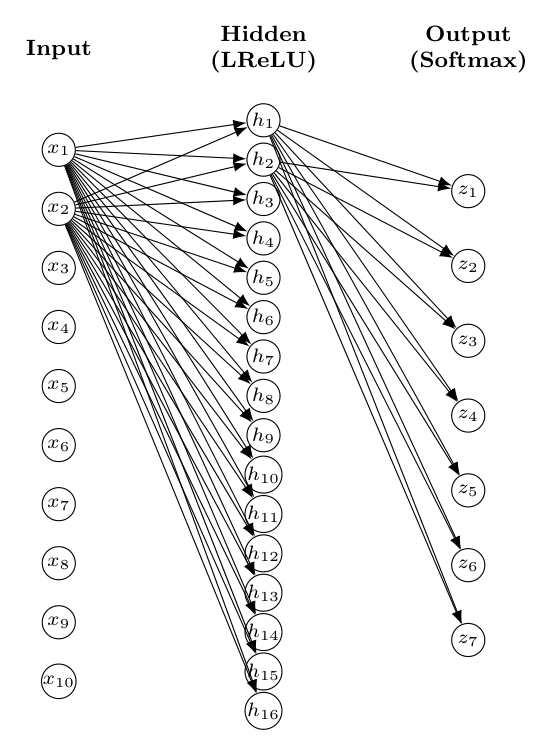

**Note:** Only the first and second neurons are connected in the diagram to avoid overwhelming lines, every layer is fully connected.

*AI was used to convert a hand-drawn sketch of the architecture into a polished LaTeX diagram.*

### 1.3 Training

We implement the neural network as modular components, a `Linear` layer, an `Activation` function, a `Network` class, and a `Loss` function. Each component handles its own forward and backward pass, making the architecture easy to extend to any number of hidden layers.

##### Linear

In [6]:
class Linear:
    def __init__(self, in_features, out_features, init_mode_weight=1, init_mode_bias=0):
        """ Randomly initialize the weights and biases.

        Args:
            in_features: number of input features.
            out_features: number of output features.

            init_mode_weight: mode of initialization for weights
              0 = all weights to zeroes (pointless but just to find out that then network does not work)
              1 = He initialization (common choice for ReLU)
              2 = Xavier initialization (rather preferred for sigmoid, but we'll try nevertheless)
              3 = Gaussian distribution
              4 = Uniform distribution: U(-0.05, 0.05)

            init_mode_bias: mode of bias initialization
              0 = all zeroes (usual choice)
              1 = bias initialized accordingly to weight mode (U(-var, var))
              (I don't think this is necessary but we are asked to randomly initialize the weights AND BIASES)
        """
        self.bias = np.zeros((out_features))

        # Initialize weights
        if init_mode_weight == 0:
            self.weight = np.zeros((out_features, in_features))
        elif init_mode_weight == 1:
            std = np.sqrt(2/in_features)
        elif init_mode_weight == 2:
            std = np.sqrt(1/in_features)
        elif init_mode_weight == 3:
            std = 1
        elif init_mode_weight == 4:
            self.weight = np.random.uniform(-0.05, 0.05, (out_features, in_features))
            if init_mode_bias == 1:
                self.bias = np.random.uniform(-0.05, 0.05, (out_features)) 

        # If weights are not initialized to 0 or 4, initialize from normal distribution
        if init_mode_weight != 0 and init_mode_weight != 4:
            self.weight = np.random.normal(0.0, std, (out_features, in_features))
            if init_mode_bias == 1:
                self.bias = np.random.uniform(-std, std, (out_features)) 
        
        # Initialize cache, weight_grad, and bias_grad
        self.cache = None
        # For storing the gradients w.r.t. the weight and the bias
        self.weight_grad = None
        self.bias_grad = None

    def forward(self, x):
        """ Perform the forward pass of a linear layer. 
        Store (cache) the input so it can be used in the backward pass.

        Args:
            x: input of a linear layer.

        Returns: 
            y: output of a linear layer. 
        """
        self.cache = x
        y = x @ self.weight.T + self.bias

        return y
    
    def backward(self, dupstream):
        """ Perform the backward pass of a linear layer.  

        Args:
            dupstream: upstream gradient. 

        Returns:
            dx: downstream gradient.
        """
        self.weight_grad = (dupstream.T @ self.cache) / self.cache.shape[0] # we divide by batch size to keep the learning rate independent of batch_size
        self.bias_grad = np.sum(dupstream, axis=0) / self.cache.shape[0] 
        dx = dupstream @ self.weight
       
        return dx

##### Activation

In [7]:
class Activation:
    def __init__(self, alpha=0.01):
        self.cache = None
        self.alpha = alpha
    
    def forward(self, x):
        """ Perform a forward pass of your activation function.
        Store (cache) the output so it can be used in the backward pass.

        Args:
            x: input to the activation function. 

        Returns:
            y: output of the activation function.
        """
        self.cache = np.where(x > 0, x, self.alpha * x)
        
        return self.cache
    
    def backward(self, dupstream): 
        """ Perform a backward pass of the activation function. 
        Make sure you do not modify the original dupstream.

        Args:
            dupstream: upstream gradient. 

        Returns:
            dx: downstream gradient.
        """
        mask = np.where(self.cache > 0, 1, self.alpha)
        dx = mask * dupstream

        return dx

##### Network

In [8]:
class Network:
    def __init__(self, layers):
        self.layers = layers

    def forward(self, x):
        """ Perform a forward pass over the entire network.

        Args:
            x: input data. 

        Returns:
            y: predictions.
        """
        for layer in self.layers:
            x = layer.forward(x)
        
        return x
    
    def backward(self, dupstream):
        """ Perform a backward pass over the entire network.

        Args:
            dupstream: upstream gradient. 

        Returns:
            dx: downstream gradient.
        """
        for layer in reversed(self.layers):
            dupstream = layer.backward(dupstream)
        
        return dupstream
    
    def optimizer_step(self, lr):
        """ Update the weight and bias parameters of each layer.

        Args:
            lr: learning rate.
        """
        
        for layer in self.layers:
            if (isinstance(layer, Linear)):
                layer.weight -= lr * layer.weight_grad
                layer.bias -= lr * layer.bias_grad

##### Loss

In [9]:
def Loss(y_true, y_pred):
    """ Computes the value of the loss function and its gradient.  

    Args:
        y_true: ground truth labels.
        y_pred: predicted labels.

    Returns:
        loss: value of the loss. 
        grad: gradient of loss with respect to the predictions. 
    """
    y_predd = np.clip(y_pred, 1e-15, 1 - 1e-15) # we do that to avoid log(0)
    loss = - np.mean(np.sum(y_true * np.log(y_predd), axis=1)) # we use mean to be consistent with weight gradients update
    grad = y_pred - y_true

    return loss, grad

##### Helpers

In [10]:
def softmax(z):
    """Numerically stable softmax."""
    # Suggested by AI to keep exponents in softmax small
    z_shifted = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def calculate_accuracy(y_pred, y_true):
    """Compute accuracy and per-class precision/recall."""
    pred_classes = np.argmax(y_pred, axis=1)
    true_classes = np.argmax(y_true, axis=1)
    accuracy = np.mean(pred_classes == true_classes)

    n_classes = y_true.shape[1]
    precision = np.zeros(n_classes)
    recall = np.zeros(n_classes)

    # Calculate precision and recall for each class
    for c in range(n_classes):
        tp = np.sum((pred_classes == c) & (true_classes == c))
        fp = np.sum((pred_classes == c) & (true_classes != c))
        fn = np.sum((pred_classes != c) & (true_classes == c))
        precision[c] = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall[c] = tp / (tp + fn) if (tp + fn) > 0 else 0

    return accuracy, precision, recall

##### Train

In [11]:
def train(net, inputs, labels, criterion, lr, batch_size=0, epochs=1000, threshold = 1e-4, steps_to_stop = 20, val_data=None):
    """
    Trains the neural network.

    Args:
        net: network or model
        inputs: input data
        labels: labels
        criterion: loss function
        lr: learning rate
        batch_size: batch size. Note: we add this to experiment with mini-batch updates
        val_data: optional (x_val, y_val_onehot) (if given, evaluates on validation set each epoch and returns their accuracies)

    Returns:
        losses: a list containing the loss at every optimizer step
        accuracies: a list containing the training accuracy at every optimizer step
        val_accuracies: list of validation accuracies per epoch (empty if val_data is None)
    """
    losses = []
    accuracies = []
    val_accuracies = []

    # If batch size is 0, set it to the number of samples in the input data
    if batch_size == 0:
        batch_size = inputs.shape[0]

    steps = 0
    prev_accuracy = 1073741823 # max int / 2

    # Training loop
    for epoch in range(epochs):
        indices = np.random.choice(inputs.shape[0], batch_size, replace=False) # choosing random indices for this batch
        x_batch = inputs[indices]

        # Following 2 lines is an AI suggested debug.
        # Previously we were taking y_batch = labels[indices], but our network expects e.g. [0, 0, 1, 0, 0, 0, 0] instead of label 3
        y_indices = labels[indices].astype(int) - 1 # we adjust for indexing from 0
        y_batch = np.eye(7)[y_indices]

        z = net.forward(x_batch)
        y_pred = softmax(z)

        loss, grad = criterion(y_batch, y_pred)
        losses.append(loss)

        grad_after = (y_pred - y_batch)  # gradient of cross-entropy + softmax simplifies to (pred - true)
        net.backward(grad_after)
        net.optimizer_step(lr)

        accuracy, _, _ = calculate_accuracy(y_pred, y_batch)
        accuracies.append(accuracy)

        # validation evaluation if requested
        if val_data is not None:
            x_val, y_val = val_data
            z_val = net.forward(x_val)
            y_val_pred = softmax(z_val)
            val_acc, _, _ = calculate_accuracy(y_val_pred, y_val)
            val_accuracies.append(val_acc)

        # If accuracy change between two epochs is very small, then we end the training
        if abs(prev_accuracy - accuracy) < threshold:
            steps += 1
        else:
            steps = 0
        if steps > steps_to_stop:
            break

        prev_accuracy = accuracy
    return losses, accuracies, val_accuracies

##### Validation

In [12]:
def k_fold_cross_validation(net, inputs, labels, criterion, lr=0.05,
                            batch_size=0, k=5, epochs=500, return_curves=False):
    """K-fold cross-validation. Returns per-fold validation accuracies.
    If return_curves=True, also returns per-epoch training/validation curves."""
    indices = np.arange(inputs.shape[0])
    np.random.shuffle(indices)
    folds = np.array_split(indices, k)

    final_train, final_val = [], []
    fold_train_curves, fold_val_curves = [], []

    # Perform k-fold cross-validation
    for i in range(k):
        net_i = copy.deepcopy(net)
        val_idx = folds[i]
        train_idx = np.concatenate([folds[j] for j in range(k) if j != i])

        x_tr, x_va = inputs[train_idx], inputs[val_idx]
        y_tr = labels[train_idx]
        y_va = np.eye(7)[labels[val_idx].astype(int) - 1]

        # Train the network
        if return_curves:
            _, train_accs, val_accs = train(
                net_i, x_tr, y_tr, criterion,
                lr=lr, batch_size=batch_size, epochs=epochs,
                val_data=(x_va, y_va)
            )
            fold_train_curves.append(train_accs)
            fold_val_curves.append(val_accs)
            final_train.append(train_accs[-1])
            final_val.append(val_accs[-1])
        else:
            train(net_i, x_tr, y_tr, criterion, lr, batch_size, epochs)
            z = net_i.forward(x_va)
            acc, _, _ = calculate_accuracy(softmax(z), y_va)
            final_val.append(acc)

    if return_curves:
        return fold_train_curves, fold_val_curves, final_train, final_val
    return final_val

##### Tests

In [13]:
# Linear layer
lin = Linear(3, 5, init_mode_weight=1)
x = np.random.randn(4, 3)
y = lin.forward(x)
assert y.shape == (4, 5), f"Linear forward: expected (4,5), got {y.shape}"
grad = np.random.randn(4, 5)
dx = lin.backward(grad)
assert dx.shape == (4, 3), f"Linear backward: expected (4,3), got {dx.shape}"
assert lin.weight_grad.shape == (5, 3), f"Weight grad shape: expected (5,3), got {lin.weight_grad.shape}"
assert lin.bias_grad.shape == (5,), f"Bias grad shape: expected (5,), got {lin.bias_grad.shape}"

# Activation
act = Activation()
out = act.forward(np.array([[-1, 0, 1], [2, -3, 0.5]]))
assert out[0, 0] == -0.01, "Leaky ReLU: negative input should be scaled by 0.01"
assert out[0, 2] == 1.0, "Leaky ReLU: positive input should pass through"
grad_act = act.backward(np.ones_like(out))
assert grad_act[0, 0] == 0.01, "Leaky ReLU gradient for negative input should be 0.01"

# Network forward/backward shapes
net_test = Network([Linear(3, 4, init_mode_weight=1), Activation(), Linear(4, 2, init_mode_weight=1)])
out = net_test.forward(np.random.randn(10, 3))
assert out.shape == (10, 2), f"Network forward: expected (10,2), got {out.shape}"
dx = net_test.backward(np.random.randn(10, 2))
assert dx.shape == (10, 3), f"Network backward: expected (10,3), got {dx.shape}"

# Softmax
logits = np.array([[1, 2, 3], [1, 1, 1]])
probs = softmax(logits)
assert np.allclose(probs.sum(axis=1), 1.0), "Softmax rows should sum to 1"
assert probs[1, 0] == probs[1, 1] == probs[1, 2], "Equal logits should give equal probs"

# Loss
y_true = np.eye(3)[[0, 1, 2]]
y_pred = softmax(np.array([[5, 0, 0], [0, 5, 0], [0, 0, 5]]))
loss_val, grad_val = Loss(y_true, y_pred)
assert loss_val < 0.1, f"Loss for confident correct predictions should be small, got {loss_val}"

# Accuracy
acc, prec, rec = calculate_accuracy(np.eye(3), np.eye(3))
assert acc == 1.0, "Perfect predictions should give 100% accuracy"

# Training convergence
net_smoke = Network([Linear(2, 4, init_mode_weight=1), Activation(), Linear(4, 7, init_mode_weight=1)])
x_smoke = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_smoke = np.array([1, 3, 5, 7])
losses_smoke, _, _ = train(net_smoke, x_smoke, y_smoke, Loss, lr=0.05, epochs=200)
assert losses_smoke[-1] < losses_smoke[0], "Loss should decrease during training"

print("All unit tests passed")

All unit tests passed


#### Question 7: How do you divide your data to ensure unbiased estimate of performance? How do you prevent data leakage?

We split the data 80/20 into training and test sets. The test set is never used during training or hyperparameter selection, it is only used for final evaluation in Question 13.

For hyperparameter tuning (Q10–Q12) we use **5-fold cross-validation** on the 80% training set, ensuring each fold serves as validation exactly once. This gives an unbiased performance estimate without touching the test set.

To prevent data leakage, z-score normalisation is fitted only on the training set and then applied to the test and unknown data using the same mean and standard deviation.

To ensure reproducibility we set a fixed seed (13) at the beginning of the notebook.

#### Question 8: How do you evaluate the performance of your network? Justify your answer.

We use two complementary metrics:

Our network is trained by minimising multiclass cross-entropy loss. Cross-entropy is the standard loss for multiclass classification because it directly penalises confident wrong predictions and produces well calibrated probability outputs.

We measure the fraction of correctly predicted labels over the total number of samples. Accuracy is appropriate here because the task is multiclass classification with roughly balanced classes, and it provides a clear, interpretable measure of overall performance.

#### Question 9: When and why do you decide to end the training?

Training ends after a fixed number of epochs. Additionally, we implement early stopping based on accuracy, if the change in training accuracy between consecutive epochs is smaller than a threshold (`1e-4`) for more than 20 consecutive steps, training stops. This prevents wasting computation once the network has converged.

#### Question 10: Train your network with different initialisation approaches. How does the initialisation impact performance?

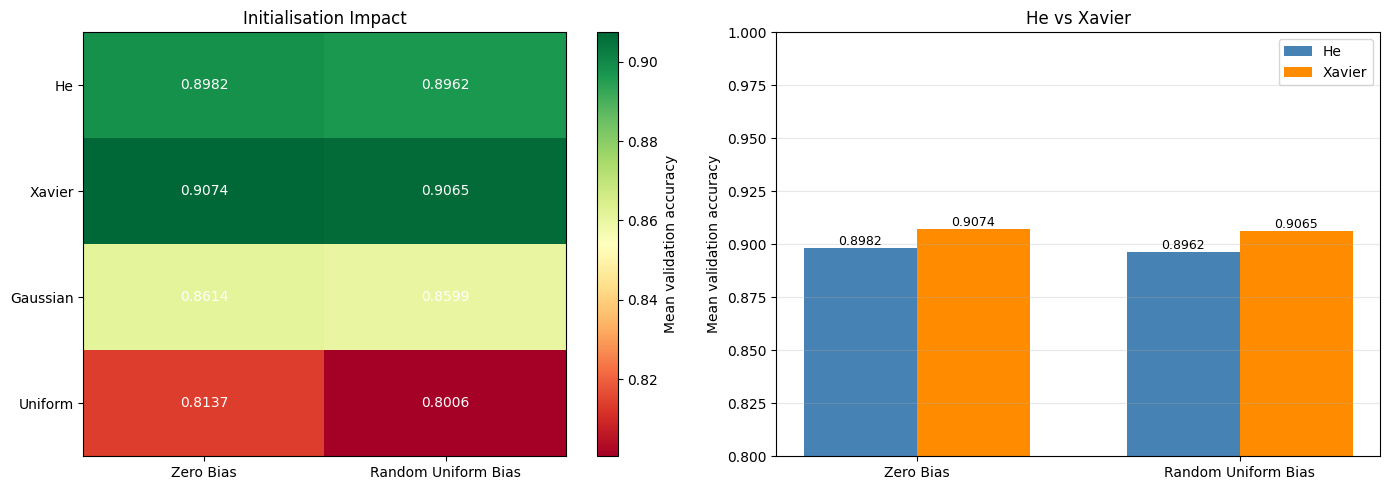

In [14]:
result_accuracies = np.zeros((4, 2))

# Evaluate different initialisation approaches
for weight_mode in [1, 2, 3, 4]:
    for bias_mode in [0, 1]:
        run_means = []

        # We run 10 random initialisations, each evaluated by k-fold CV
        for _ in range(10):
            net = Network([
                Linear(10, 16, init_mode_weight=weight_mode, init_mode_bias=bias_mode),
                Activation(),
                Linear(16, 7, init_mode_weight=weight_mode, init_mode_bias=bias_mode)
            ])
            val_accs = k_fold_cross_validation(
                net, features_train, targets_train, Loss, lr=0.05, k=5, epochs=250)
            run_means.append(np.mean(val_accs))
        result_accuracies[weight_mode - 1, bias_mode] = np.mean(run_means)

weight_labels = ['He', 'Xavier', 'Gaussian', 'Uniform']
bias_labels = ['Zero Bias', 'Random Uniform Bias']

# Heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].imshow(result_accuracies, cmap='RdYlGn', aspect='auto')
plt.colorbar(im, ax=axes[0], label='Mean validation accuracy')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(bias_labels)
axes[0].set_yticks(range(4))
axes[0].set_yticklabels(weight_labels)
axes[0].set_title('Initialisation Impact')
for i in range(4):
    for j in range(2):
        axes[0].text(j, i, f'{result_accuracies[i,j]:.4f}', ha='center', va='center', color='white')

# He vs Xavier bar chart
x = np.arange(2)
w = 0.35
bars1 = axes[1].bar(x - w/2, result_accuracies[0], w, label='He', color='steelblue')
bars2 = axes[1].bar(x + w/2, result_accuracies[1], w, label='Xavier', color='darkorange')
axes[1].set_ylabel('Mean validation accuracy')
axes[1].set_title('He vs Xavier')
axes[1].set_xticks(x)
axes[1].set_xticklabels(bias_labels)
axes[1].legend()
axes[1].set_ylim(0.8, 1.0)
axes[1].grid(True, alpha=0.3, axis='y')
for bars in [bars1, bars2]:
    for bar in bars:
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                     f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

We observe that **He and Xavier initialisation** perform significantly better than Gaussian and Uniform. Between He and Xavier, results are nearly identical the difference is about 1%, likely within random variation.

Bias initialisation (zero vs random uniform) has minimal impact for He and Xavier but degrades performance slightly for Gaussian and Uniform initialisations.

We select **He initialisation with zero bias** as our default, since it consistently achieves high accuracy and is the standard choice for ReLU type activations.


### 1.4 Optimisation

#### Question 11: Train your network with different amounts of hidden neurons and plot performance vs. number of hidden neurons.

We keep the same architecture and hyperparameters as before and only vary the number of hidden neurons.
For each size we run several training runs on the fixed train/validation split and average the validation accuracies.

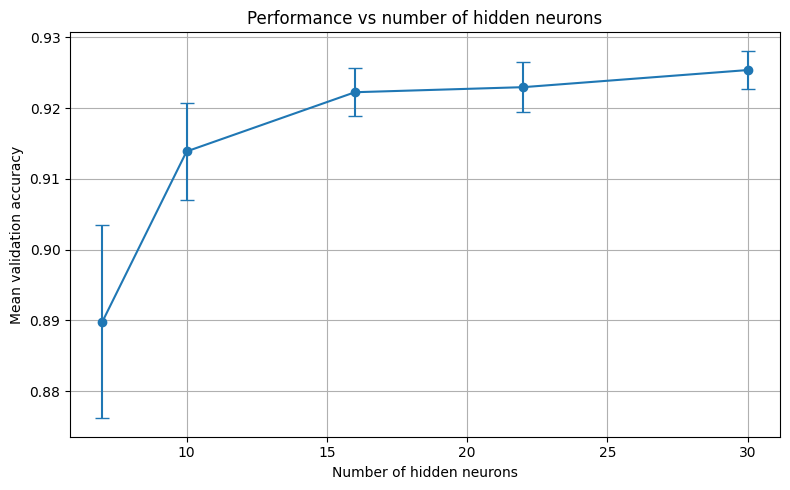

n_hidden =  7, mean accuracy = 0.8898 ± 0.0137
n_hidden = 10, mean accuracy = 0.9139 ± 0.0068
n_hidden = 16, mean accuracy = 0.9223 ± 0.0034
n_hidden = 22, mean accuracy = 0.9230 ± 0.0035
n_hidden = 30, mean accuracy = 0.9254 ± 0.0027


In [15]:
hidden_neurons = [7, 10, 16, 22, 30]
epochs = 500

mean_accuracies = []
std_accuracies = []

# Evaluate different hidden layer sizes
for n_hidden in hidden_neurons:
    run_means = []

    # We run 10 random initialisations, each evaluated by k-fold CV
    for i in range(10):
        net = Network([
            Linear(10, n_hidden, init_mode_weight=1),
            Activation(),
            Linear(n_hidden, 7, init_mode_weight=1)
        ])

        val_accs = k_fold_cross_validation(net, features_train, targets_train,
                                           Loss, lr=0.05, k=5, epochs=epochs)
        run_means.append(np.mean(val_accs))

    mean_accuracies.append(np.mean(run_means))
    std_accuracies.append(np.std(run_means))

hidden_neurons = np.array(hidden_neurons)
mean_accuracies = np.array(mean_accuracies)
std_accuracies = np.array(std_accuracies)

# Plot the results
plt.figure(figsize=(8, 5))
plt.errorbar(hidden_neurons, mean_accuracies, yerr=std_accuracies, fmt='-o', capsize=5)
plt.xlabel('Number of hidden neurons')
plt.ylabel('Mean validation accuracy')
plt.title('Performance vs number of hidden neurons')
plt.grid(True)
plt.tight_layout()
plt.show()

for n_hidden, mean_acc, std_acc in zip(hidden_neurons, mean_accuracies, std_accuracies):
    print(f'n_hidden = {n_hidden:2d}, mean accuracy = {mean_acc:.4f} ± {std_acc:.4f}')

We tested hidden layer sizes `[7, 10, 16, 22, 30]` with all other hyperparameters fixed. Small layers (7-10) underfit due to insufficient capacity, while larger layers provide slower training and potential overfitting with diminishing returns, consistent with the bias-variance tradeoff.

#### Question 12: Plot the training and validation performance of your best architecture across epochs. Justify your choice.

Training accuracy (mean over folds): 0.9269
Validation accuracy (mean over folds): 0.9238


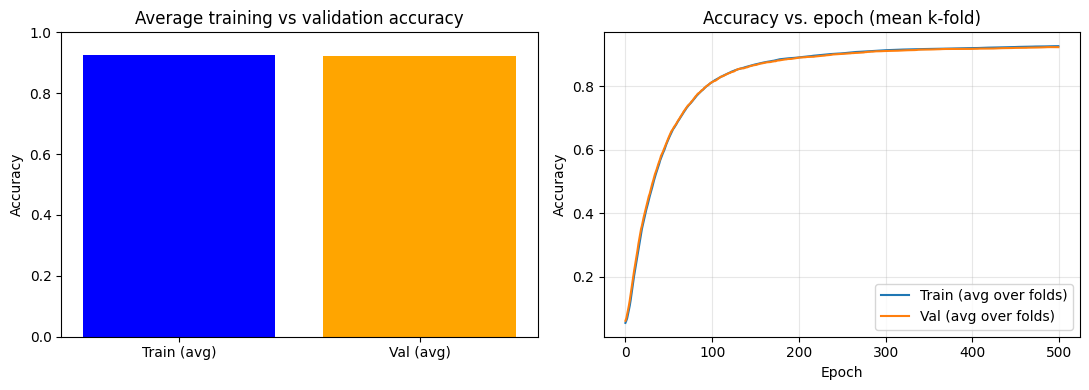

In [16]:
# 1 hidden layer, 16 neurons
net_q12 = Network([
    Linear(10, 16, init_mode_weight=1),
    Activation(),
    Linear(16, 7, init_mode_weight=1)
])

# Training on the 80% training data with 5-fold cross-validation
(train_curves_q12,
 val_curves_q12,
 train_accs_q12,
 val_accs_q12) = k_fold_cross_validation(net_q12,
                                          features_train,
                                          targets_train,
                                          Loss,
                                          lr=0.05, k=5, epochs=500,
                                          return_curves=True)

# Pad ragged curves to equal length (folds may stop at different epochs)
max_len = max(len(c) for c in train_curves_q12)
train_padded = np.array([c + [c[-1]] * (max_len - len(c)) for c in train_curves_q12])
val_padded = np.array([c + [c[-1]] * (max_len - len(c)) for c in val_curves_q12])

mean_train_curve = train_padded.mean(axis=0)
mean_val_curve = val_padded.mean(axis=0)

avg_train_acc = np.mean(train_accs_q12)
avg_val_acc = np.mean(val_accs_q12)
print(f"Training accuracy (mean over folds): {avg_train_acc:.4f}")
print(f"Validation accuracy (mean over folds): {avg_val_acc:.4f}")

# Bar plot comparison
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(['Train (avg)', 'Val (avg)'], [avg_train_acc, avg_val_acc], color=['blue', 'orange'])
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Average training vs validation accuracy')

# Epoch-wise curves
axes[1].plot(mean_train_curve, label='Train (avg over folds)')
axes[1].plot(mean_val_curve, label='Val (avg over folds)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy vs. epoch (mean k-fold)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Based on the results from question 11, we chose **16 hidden neurons** because it achieves strong validation accuracy while keeping model complexity low (`mean accuracy = 0.9192 ± 0.0026`). The 10–16–7 architecture provides a good tradeoff between underfitting and overfitting.

### 1.5 Evaluation

#### Question 13: What is the success rate on the test set? How does it compare to the validation set?


Mean validation accuracy (k-fold): 0.9238
Test accuracy (80% train): 0.9153
Difference (test - validation): -0.0084


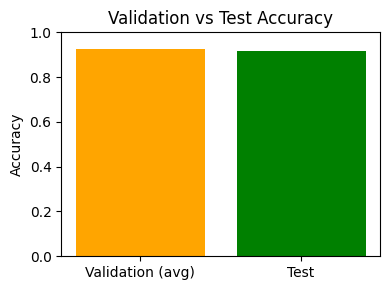

In [17]:
# Retrain the chosen architecture on the entire 80% training split.
# According to our earlier experiments (Question 11) the best configuration
# was a single hidden layer with 16 neurons, so we use a 10–16–7 network here.
net_final = Network([
    Linear(10, 16, init_mode_weight=1),
    Activation(),
    Linear(16, 7, init_mode_weight=1)
])

train(net_final, features_train, targets_train, Loss, lr=0.05, epochs=500)

test_class_indices = targets_test.astype(int) - 1
y_test_one_hot = np.eye(7)[test_class_indices]

# Evaluate on reserved 20% test set
z_test = net_final.forward(features_test)
y_pred_test = softmax(z_test)

test_acc, _, _ = calculate_accuracy(y_pred_test, y_test_one_hot)


# Compare with average validation accuracy from Q12 cross-validation
print(f"Mean validation accuracy (k-fold): {avg_val_acc:.4f}")
print(f"Test accuracy (80% train): {test_acc:.4f}")
print(f"Difference (test - validation): {test_acc - avg_val_acc:+.4f}")

plt.figure(figsize=(4, 3))
plt.bar(['Validation (avg)', 'Test'], [avg_val_acc, test_acc], color=['orange', 'green'])
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Validation vs Test Accuracy')
plt.tight_layout()
plt.show()

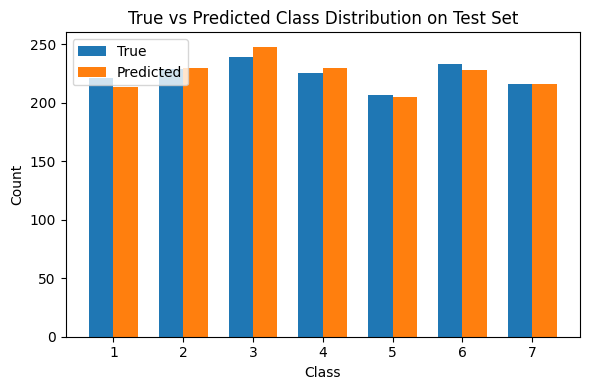

In [18]:
# Distribution of true vs predicted classes on test set
true_counts = np.bincount(test_class_indices, minlength=7)
pred_counts = np.bincount(np.argmax(y_pred_test, axis=1), minlength=7)
plt.figure(figsize=(6, 4))
indices = np.arange(1, 8)
width = 0.35
plt.bar(indices - width/2, true_counts, width, label='True')
plt.bar(indices + width/2, pred_counts, width, label='Predicted')
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('True vs Predicted Class Distribution on Test Set')

plt.legend()
plt.tight_layout()
plt.show()

We retrain the network on the entire 80% of the train data (before the accuracies were averaged over the 5 fold splits). Testing this on the reserved test gives us a slightly lower accuracy than the average validation accuracy over the folds (0.79% lower).

This is because the test data was not used in tuning the weights, and we get a single accuracy score rather than an average over the folds making our accuracy more inconsistent and varied. These accuracies depend on the random seed we set, leading to different initial data splits and random weight initalizations.

#### Question 14: Show and discuss a confusion matrix on the test set.

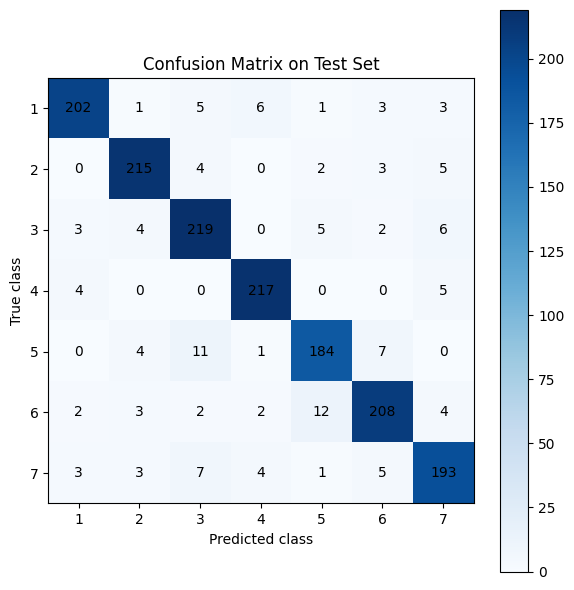

In [19]:
# Compute 7x7 confusion matrix on test set
y_true = targets_test.astype(int) - 1
y_pred_class = np.argmax(y_pred_test, axis=1)
cm = np.zeros((7, 7), dtype=int)
for t, p in zip(y_true, y_pred_class):
    cm[t, p] += 1

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(cm, cmap='Blues', interpolation='nearest')
plt.colorbar(im)
ax.set_xticks(range(7))
ax.set_xticklabels(range(1, 8))
ax.set_yticks(range(7))
ax.set_yticklabels(range(1, 8))
ax.set_xlabel('Predicted class')
ax.set_ylabel('True class')
ax.set_title('Confusion Matrix on Test Set')
for i in range(7):
    for j in range(7):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.tight_layout()
plt.show()

The diagonal entries show correctly classified samples, the higher these values, the better the network performs for that class. Off-diagonal entries indicate misclassifications, where the row is the true class and the column is what the network predicted instead.

Most of the mass lies on the diagonal, confirming the high overall accuracy. The largest off-diagonal entries reveal the most common confusions:

- Class 7 to Class 2 (11 errors): the single largest confusion in the matrix. Class 7 samples are often predicted as class 2.
- Class 5 to Class 3 (10 errors): class 5 samples are most frequently misclassified as class 3, suggesting these two classes share similar feature patterns.
- Class 5 to Class 6 (9 errors): class 5 is also confused with class 6, making it the weakest class overall (186 correct out of 207).

Class 4 has the strongest performance (217 correct, only 6 errors), while class 5 is the hardest to classify. The errors are spread across multiple pairs rather than concentrated in one, suggesting no single class dominates the mistakes.

#### Question 15: Predict the unknown samples and report the autograder score.

In [20]:
# Note that for this question, we train on 100% of the data, since Vocareum is the test set

features_all = np.vstack([features_train, features_test])
targets_all = np.concatenate([targets_train, targets_test])

net_all = Network([
    Linear(10, 16, init_mode_weight=1),
    Activation(),
    Linear(16, 7, init_mode_weight=1)
])

train(net_all, features_all, targets_all, Loss, lr=0.05, epochs=500)

z_unknown = net_all.forward(unknown)
predicted_classes = np.argmax(softmax(z_unknown), axis=1) + 1

# Export predictions
output_filename = "../data/61_classes.txt"
predictions_str = ','.join(f'{x:.18e}' for x in predicted_classes)
with open(output_filename, 'w') as f:
    f.write(predictions_str)

### 1.6 Scikit-learn

#### Question 16: Run the scikit-learn grid search notebook and compare the optimised parameters with yours.

We ran the provided scikit-learn grid search notebooks with the following search grid:

- hidden_layer_sizes: `(16,), (20,), (32,), (64,), [64, 32], [32, 16]`
- activation: `identity, logistic, tanh, relu`
- alpha (L2 penalty): `0.001, 0.01, 0.1`
- solver: `sgd, adam`
- learning_rate_init: `0.005, 0.01`

This resulted in 288 candidate configurations, each evaluated with 5-fold cross-validation (1440 fits total). The best parameters found were:

| Parameter | Scikit-learn (best) | Our network |
|-----------|-------------------|-------------|
| Hidden layer | (32,) | (16,) |
| Activation | tanh | Leaky ReLU |
| Solver | SGD | SGD |
| Learning rate | 0.01 | 0.05 |
| Regularisation | α = 0.1 (L2) | None |

The main differences are: 
1. Scikit-learn prefers `tanh` over Leaky ReLU
2. It chose a lower learning rate with L2 regularisation
3. It selected a larger hidden layer (32 vs 16)

The scikit-learn network achieved 93.4% training accuracy and 93.6% test accuracy, compared to our network's validation accuracy of approximately 92%. The performance gap is likely due to scikit-learn's momentum, L2 regularisation, and early stopping mechanisms.

#### Question 17: Plug the scikit-learn parameters into your network. Does performance improve?

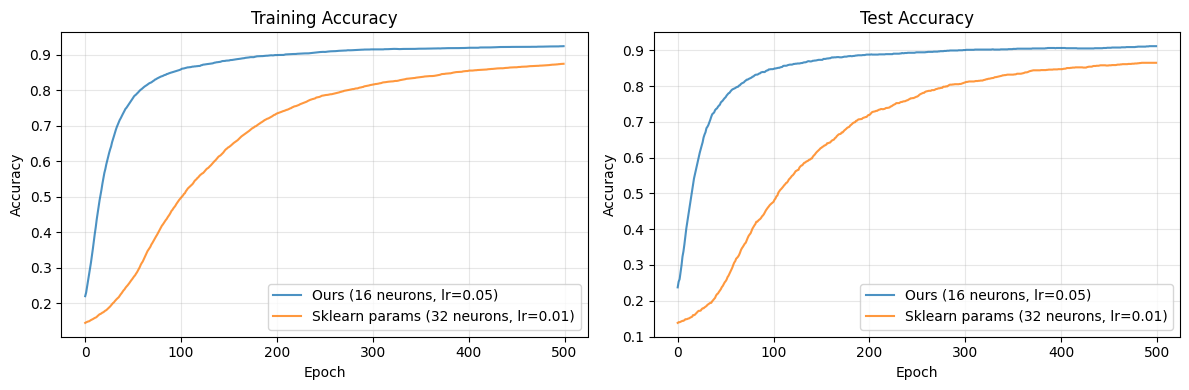

Our network - train: 0.9249, test: 0.9115
Sklearn params - train: 0.8752, test: 0.8651


In [21]:
# Best params from grid search: 32 hidden neurons, tanh, lr=0.01, SGD, alpha=0.1

# Use scikit-learn's hidden layer size (32) and learning rate (0.01)
net_sklearn_params = Network([
    Linear(10, 32, init_mode_weight=1),
    Activation(),
    Linear(32, 7, init_mode_weight=1)
])

test_onehot = np.eye(7)[targets_test.astype(int) - 1]

_, sklearn_accs, sklearn_val = train(
    net_sklearn_params, features_train, targets_train, Loss,
    lr=0.01, epochs=500, val_data=(features_test, test_onehot)
)

# Our original setup for comparison
net_ours = Network([
    Linear(10, 16, init_mode_weight=1),
    Activation(),
    Linear(16, 7, init_mode_weight=1)
])

_, our_accs, our_val = train(
    net_ours, features_train, targets_train, Loss,
    lr=0.05, epochs=500, val_data=(features_test, test_onehot)
)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(our_accs, label='Ours (16 neurons, lr=0.05)', alpha=0.8)
axes[0].plot(sklearn_accs, label='Sklearn params (32 neurons, lr=0.01)', alpha=0.8)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Training Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(our_val, label='Ours (16 neurons, lr=0.05)', alpha=0.8)
axes[1].plot(sklearn_val, label='Sklearn params (32 neurons, lr=0.01)', alpha=0.8)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Test Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Our network - train: {our_accs[-1]:.4f}, test: {our_val[-1]:.4f}")
print(f"Sklearn params - train: {sklearn_accs[-1]:.4f}, test: {sklearn_val[-1]:.4f}")

Adopting scikit-learn's parameters does not improve our network's performance.

The lower learning rate (0.01 vs 0.05) causes slower convergence, and our network lacks scikit-learn's built in momentum (0.9) and adaptive schedule. The larger hidden layer (32 vs 16) adds capacity but not accuracy.

The parameters don't transfer because:
1. Scikit-learn chose `tanh`, we use Leaky ReLU with different gradient dynamics
2. Scikit-learn uses L2 (α = 0.1), which we haven't implemented
3. Scikit-learn uses momentum, early stopping, and mini-batches, while ours is vanilla full-batch SGD

We retain our original parameters (16 hidden neurons, `lr = 0.05`).

### 1.7 Reflection

#### Question 18: Give an example of misclassification and harmful consequences from bias.

An example is the misclassification due to bias can be found in medical AI systems used to detect skin cancer. If a model is primarily trained on images of lighter skin tones, it may less accurately on darker skin and incorrectly classify malignent lesions benign. This systematic error can delay diagnosis and treatment, even though early detection is essential for effective outcomes. As a result, patients may face avoidable complications or reduced chances of recovery. Such biased performance not only harms individuals directly, but can also reinforce existing inequalities in healthcare access and quality.

#### Question 19: How can we mitigate harm from unjust classification? Give two approaches.

One approach to mitigating harm from unjust classification is to ensure a more representative data collection for training systems. Ensuring that datasets include diverse populations can reduce systematic performance differences between groups and limit discriminatory errors. However, data improvement alone is not sufficient, since bias can still arise from how systems are designed, deployed or interpreted.

A second approach is to introduce instutitinal oversight and accountability mechanism. For example, regular independent audits could be organised to check whether the model performs equally well across different skin tones. Organisations could also be required to report how the model was trained and to disclose performance metrics for different subgroups. In addition, doctors should not solely rely on the model's output, but should review and confirm results.

Implementing these measures does not guarantee that the problem is fully solved, as bias may persist due to incomplete data, changing population characteristcs or unintended consequences of model updates. Therefore, ongoing evaluation, ethical oversight and collaboration between technical experts and healthcare professionals remain essential.

### 1.8 Pen and paper

#### Question 20: Find the inputs for the neural network using max pooling and the sharpen kernel.

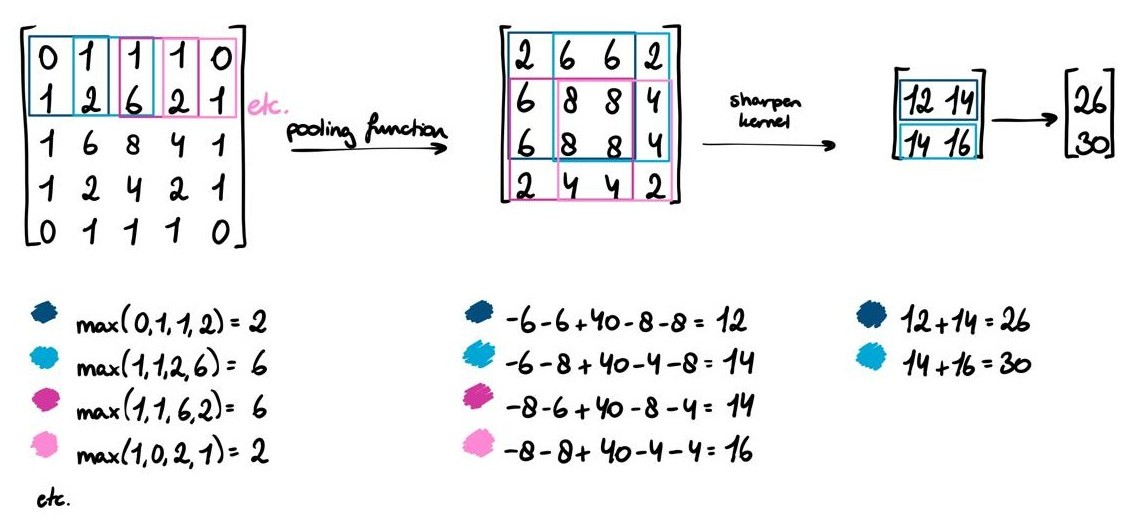

#### Question 21: Use the inputs found in Q20 and the given network architecture to find the output on neuron y.

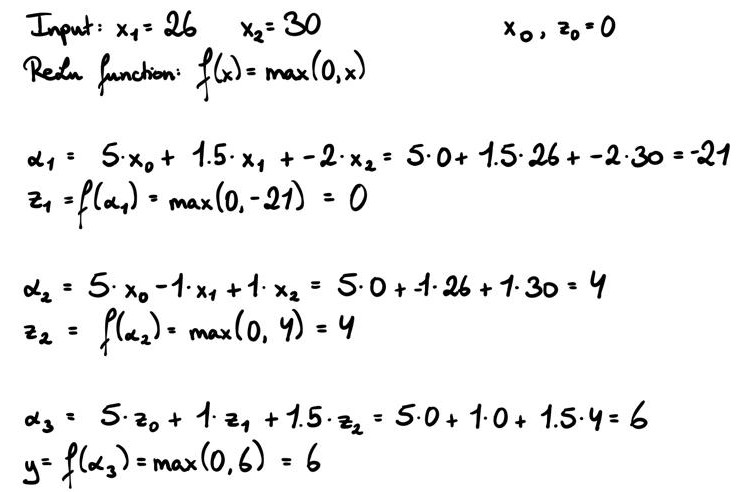

### 1.9 Division of work

#### Question 22: Indicate each group member's contribution.

|          Component          |    Eva    |  Iasonas  |    Guy    |   Miłosz  |
|-----------------------------|-----------|-----------|-----------|----------|
| Code (design)               |    20%    |    30%    |    25%    |    25%   |
| Code (implementation)       |    25%    |    25%    |    30%    |    20%   |
| Code (validation)           |    30%    |    20%    |    25%    |    25%   |
| Experiments (execution)     |    25%    |    25%    |    25%    |    25%   |
| Experiments (analysis)      |    20%    |    30%    |    25%    |    25%   |
| Experiments (visualisation) |    25%    |    25%    |    20%    |    30%   |
| Report (original draft)     |    30%    |    20%    |    25%    |    25%   |
| Report (reviewing & editing)|    25%    |    25%    |    25%    |    25%   |

### References

- Generative AI was used for help with the following:
    - **Markdown**: for example, making tables in Markdown or a diagram of the network
    - Assistance with debugging (e.g., noticing the need to change values into one-hot)
    - Suggestions (mentioned in the code), and verification that the code is correct
    - Lastly, it was used for assistance for refintment of plots via `matplotlib`
- [Who's Adam and What's He Optimizing? | Deep Dive into Optimizers for Machine Learning!](https://www.youtube.com/watch?v=MD2fYip6QsQ&)
-  [Neural Networks - 3Blue1Brown](https://youtube.com/playlist?list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi&si=9n6Ga6z4jPcBdt_f)